# Завдання
## Оберіть самостійно реальний часовий ряд(data_migration.xlsx). Реалізуйте побудову його моделі та прогнозування
## поведінки часового ряду поза межами інтервалу спостереження з
## використанням рекурентних нейронних мереж. Доведіть ефективність рішень.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings

warnings.filterwarnings('ignore')


# Load and clean

In [2]:
def load_and_prepare_data() -> pd.DataFrame:
    df = pd.read_excel('data/dataset_MIGRATION.xlsx')
    df = df.rename(columns={c: c.strip() for c in df.columns})

    period_cols = [
        c for c in df.columns if isinstance(c, str) and (c.isdigit() or '-' in c and c.split('-')[0].isdigit())
    ]

    df = df.melt(['Територіальний розріз', 'Країна в\'їзду/виїзду', 'Стать', 'Вік'],
                 value_vars=period_cols,
                 var_name='Period',
                 value_name='Migrants')
    df['Period'] = pd.to_datetime(df['Period'], format='%Y-%m', errors='coerce').fillna(pd.to_datetime
                                                                                        (df[
                                                                                             'Period'].str[
                                                                                             :4],
                                                                                         format='%Y',
                                                                                         errors='coerce'))
    df = df.dropna(subset=['Period'])

    clean_df = df.rename(columns={
        'Територіальний розріз': 'District',
        "Країна в'їзду/виїзду": 'Country',
        'Стать': 'Gender',
        'Вік': 'Age'
    })
    for col in ['Gender', 'Age']:
        clean_df[col] = clean_df[col].replace('Усього', np.nan)

    clean_df.drop('Country', axis=1, inplace=True)
    clean_df.dropna(inplace=True)

    return clean_df


df = load_and_prepare_data()

# Aggregate country

In [14]:
def aggregate_country(df: pd.DataFrame, country_name: str = 'Україна') -> pd.Series:
    d = df[df['District'] == country_name].copy()
    # aggregating by date (yearly)
    ts = d.groupby('Period')['Migrants'].sum().sort_index()
    ts = ts.resample('Y').sum()
    ts.index = ts.index.to_period('Y').to_timestamp()
    return ts


ts = aggregate_country(df, country_name='Україна')
print(ts.head(10))

values = ts.values.astype(float)
years = ts.index.year

Period
2002-01-01    1604956.0
2003-01-01    1603044.0
2004-01-01    1655892.0
2005-01-01    1605604.0
2006-01-01    1620218.0
2007-01-01    1609598.0
2008-01-01    1496226.0
2009-01-01    1351472.0
2010-01-01    1428518.0
2011-01-01    1402162.0
Freq: YS-JAN, Name: Migrants, dtype: float64


# Prepare LSTM

In [4]:
def create_sequences(values: np.ndarray, lookback: int = 5, horizon: int = 1) -> Tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    N = len(values)
    for i in range(N - lookback - horizon + 1):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback:i + lookback + horizon])
    X = np.array(X)
    y = np.array(y)
    return X, y


# train/val/test split: last 5 years, before 5 years
test_years = 5
val_years = 5
n = len(values)
if n < (test_years + val_years + 10):
    print('Warning - insufficient years')
train_end = n - (val_years + test_years)
val_end = n - test_years

train_vals = values[:train_end]
val_vals = values[train_end:val_end]
test_vals = values[val_end:]

# scaling on train only
scaler = StandardScaler()
scaler = scaler.fit(train_vals.reshape(-1, 1))

lookback = 5  # last 5 years as a window
horizon = 1

# using train only for fit and val for EarlyStop
train_seq_X, train_seq_y = create_sequences(scaler.transform(train_vals.reshape(-1, 1)).flatten(), lookback, horizon)
val_seq_X, val_seq_y = create_sequences(
    scaler.transform(np.concatenate([train_vals[-lookback:], val_vals]).reshape(-1, 1)).flatten(), lookback, horizon)

# Model

In [5]:
def build_lstm(input_shape: Tuple[int, int], units=64, dropout=0.2) -> tf.keras.Model:
    model = Sequential()
    model.add(LSTM(units, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(units // 2, activation='relu'))
    model.add(Dense(1))  # horizon =1
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# reshaping for LSTM: (samples, timesteps, features)
train_X = train_seq_X.reshape((train_seq_X.shape[0], train_seq_X.shape[1], 1))
train_y = train_seq_y.reshape((train_seq_y.shape[0], train_seq_y.shape[1]))
val_X = val_seq_X.reshape((val_seq_X.shape[0], val_seq_X.shape[1], 1))
val_y = val_seq_y.reshape((val_seq_y.shape[0], val_seq_y.shape[1]))

print('Shapes:', train_X.shape, train_y.shape, val_X.shape, val_y.shape)

model = build_lstm(input_shape=(lookback, 1), units=64, dropout=0.2)
es = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)

history = model.fit(train_X, train_y, validation_data=(val_X, val_y),
                    epochs=500, batch_size=8, callbacks=[es], verbose=1)

# Forecast test one-step ahead by sliding window
# prepare sequence: last lookback values from val+train
full_scaled = scaler.transform(values.reshape(-1, 1)).flatten()
preds = []
cur_seq = full_scaled[-(test_years + lookback):-test_years] if test_years > 0 else full_scaled[-lookback:]
seq_for_preds = full_scaled[-(test_years + lookback):]  #lookback + test block
for i in range(test_years):
    window = seq_for_preds[i:i + lookback]
    Xp = window.reshape((1, lookback, 1))
    yhat_scaled = model.predict(Xp, verbose=0)[0][0]
    preds.append(yhat_scaled)
    seq_for_preds = np.append(seq_for_preds, full_scaled[-test_years + i])  # append actual
# inverse scale
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
actual = values[-test_years:]

print('Actual:', actual)
print('Predictions:', preds_inv)



Shapes: (5, 5, 1) (5, 1) (5, 5, 1) (5, 1)


2025-12-11 12:10:24.405559: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-12-11 12:10:24.405613: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-12-11 12:10:24.405617: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2025-12-11 12:10:24.405667: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-11 12:10:24.405680: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/500


2025-12-11 12:10:25.825721: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 1.3845 - mae: 1.0787 - val_loss: 24.2820 - val_mae: 3.7036
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.3306 - mae: 1.0522 - val_loss: 24.1965 - val_mae: 3.6990
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.2903 - mae: 1.0358 - val_loss: 24.1007 - val_mae: 3.6940
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.2602 - mae: 1.0172 - val_loss: 24.0151 - val_mae: 3.6896
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.2393 - mae: 1.0160 - val_loss: 23.9047 - val_mae: 3.6834
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.1767 - mae: 0.9758 - val_loss: 23.7811 - val_mae: 3.6762
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 1.1351 - mae: 0.9609 - val_loss: 23.6497 - val_mae: 3.6683
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.1398 - mae: 0.9613 - val_loss: 23.5193 - val_mae: 3.6605
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.1133 - mae: 0.965

# Grades

In [13]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {'MAE': f'{mae:.2f}', 'RMSE': f'{rmse:.2f}', 'MAPE': f'{mape:.2f}'}


metrics = evaluate_forecast(actual, preds_inv)
print('Metrics:', metrics)

# Baseline: naive (last observed)
naive_preds = np.repeat(values[val_end - 1], test_years)
print('Naive metrics:', evaluate_forecast(actual, naive_preds))

Metrics: {'MAE': '195953.75', 'RMSE': '225540.78', 'MAPE': '19.51'}
Naive metrics: {'MAE': '553987.20', 'RMSE': '578138.80', 'MAPE': '49.44'}


# Plots

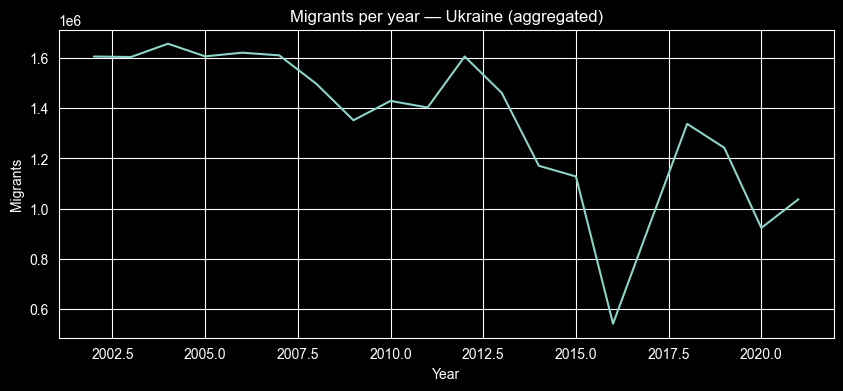

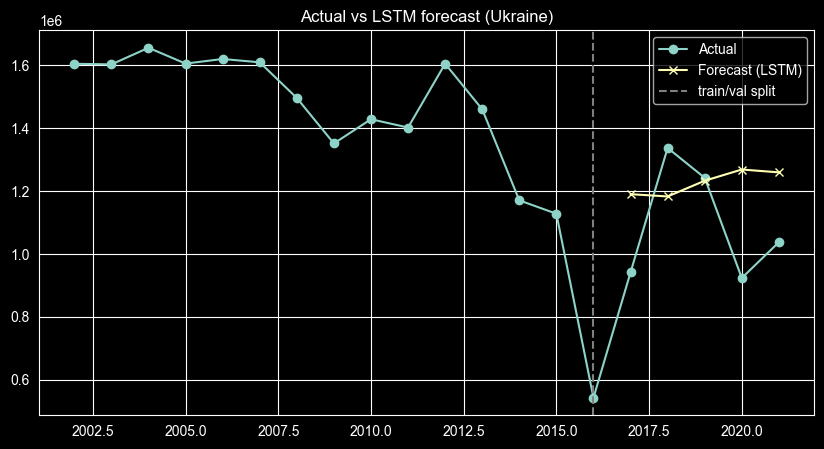

In [7]:
plt.figure(figsize=(10, 4))
sns.lineplot(x=ts.index.year, y=ts.values)
plt.title('Migrants per year — Ukraine (aggregated)')
plt.xlabel('Year')
plt.ylabel('Migrants')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(years, values, label='Actual', marker='o')
plt.plot(years[-test_years:], preds_inv, label='Forecast (LSTM)', marker='x')
plt.axvline(x=years[val_end - 1], color='gray', linestyle='--', label='train/val split')
plt.legend()
plt.title('Actual vs LSTM forecast (Ukraine)')
plt.show()

# run pipeline

In [9]:
def run_pipeline(df: pd.DataFrame):
    # districts = df['District'].unique()[:10]  # 10 for test purpose
    districts = df['District'].unique()
    district_forecasts = {}
    for d in districts:
        dser = df[df['District'] == d].groupby('Period')['Migrants'].sum().resample('Y').sum().sort_index()
        vals = dser.values.astype(float)
        if len(vals) < (lookback + test_years + 2):
            continue
        scaler_d = StandardScaler().fit(vals.reshape(-1, 1))
        full_scaled_d = scaler_d.transform(vals.reshape(-1, 1)).flatten()
        # train simple sequences as above but with fewer epochs / small model for speed
        Xd, yd = create_sequences(full_scaled_d[:-test_years], lookback, horizon)
        if len(Xd) < 10:
            continue
        Xd = Xd.reshape((Xd.shape[0], Xd.shape[1], 1))
        yd = yd.reshape((yd.shape[0], yd.shape[1]))
        m = build_lstm(input_shape=(lookback, 1), units=32, dropout=0.2)
        m.fit(Xd, yd, epochs=50, batch_size=4, verbose=0)
        # predict last test_years one-step
        preds_d = []
        seq_for_preds_d = full_scaled_d[-(test_years + lookback):]
        for i in range(test_years):
            window = seq_for_preds_d[i:i + lookback]
            yhat = m.predict(window.reshape(1, lookback, 1), verbose=0)[0][0]
            preds_d.append(yhat)
            seq_for_preds_d = np.append(seq_for_preds_d, full_scaled_d[-test_years + i])
        preds_d_inv = scaler_d.inverse_transform(np.array(preds_d).reshape(-1, 1)).flatten()
        district_forecasts[d] = preds_d_inv

    # Aggregate district forecasts (bottom-up) for test horizon
    if district_forecasts:
        agg_forecast = np.sum(np.vstack([v for v in district_forecasts.values()]), axis=0)
        # compare to actual aggregate
        actual_agg = values[-len(agg_forecast):]
        print('Bottom-up aggregate metrics:', evaluate_forecast(actual_agg, agg_forecast))
    else:
        print('No district forecasts (not enough data per district)')

    return {'model': model, 'scaler': scaler, 'metrics': metrics, 'preds': preds_inv, 'actual': actual}


res = run_pipeline(df)

Bottom-up aggregate metrics: {'MAE': 560813.85, 'RMSE': 608757.5976362071, 'MAPE%': 54.881938156163116}
